# Multiclass Classification on the UCI Seeds Dataset Using a Feed-Forward ANN

This notebook builds and evaluates a feed-forward Artificial Neural Network (ANN) for multiclass classification on the UCI Seeds dataset.  

We follow these steps:
1. Data loading and EDA  
2. Preprocessing (split + scaling)  
3. ANN design and training (two variants)  
4. Hyperparameter comparison  
5. Final evaluation (metrics + confusion matrix)


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Deep learning (Keras / TensorFlow)
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical

# Reproducibility: fix all random seeds
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


**Imports & Reproducibility**

In [2]:
# Column names given in the assignment
col_names = [
    "area",
    "perimeter",
    "compactness",
    "length_of_kernel",
    "width_of_kernel",
    "asymmetry_coefficient",
    "length_of_kernel_groove",
    "class"
]

# Load the UCI Seeds dataset
# The original file usually has whitespace-separated values, no header
df = pd.read_csv("seeds_dataset.txt",
                 delim_whitespace=True,
                 header=None,
                 names=col_names)

# Quick peek at the data
df.head()


/tmp/ipython-input-1939173427.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("seeds_dataset.txt",


,area,perimeter,compactness,length_of_kernel,width_of_kernel,asymmetry_coefficient,length_of_kernel_groove,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


**EDA: Class Distribution & Summary Stats**

In [3]:
# Check dataset shape
print("Dataset shape:", df.shape)

# Class distribution
print("\nClass distribution:")
print(df["class"].value_counts().sort_index())

# Per-feature summary stats (mean, std)
feature_cols = col_names[:-1]

print("\nPer-feature mean and std:")
feature_stats = df[feature_cols].agg(['mean', 'std'])
feature_stats


Dataset shape: (210, 8)

Class distribution:
class
1    70
2    70
3    70
Name: count, dtype: int64

Per-feature mean and std:


,area,perimeter,compactness,length_of_kernel,width_of_kernel,asymmetry_coefficient,length_of_kernel_groove
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480


In this notebook, I tried to keep the workflow simple and clear so I can follow each step myself. First, I imported the basic Python libraries like NumPy, pandas, matplotlib, and some tools from scikit-learn. These are needed for working with the dataset, scaling the features, splitting the data, and calculating the evaluation metrics. I also set the random seeds for reproducibility so that the results stay the same every time the notebook is run.

After that, I loaded the Seeds dataset from the text file and gave the columns the eight names provided in the assignment. To understand the data a little better, I printed the dataset shape, the class distribution, and some summary statistics such as mean and standard deviation for each feature. I also checked for missing values, although none were found in this dataset.

Next, I separated the features (X) and the target variable (y). Since the class labels were 1, 2, and 3, I converted them to 0, 1, and 2 because neural networks usually work better with zero-based indexing. Then I did an 80/20 train-test split using stratification so that all three classes are represented properly in both sets. I scaled the features with StandardScaler to put everything on the same scale, which helps neural networks train more efficiently. I also converted the labels into one-hot vectors so that they match the softmax output.

For the model, I created a function called `build_mlp` that constructs a two-hidden-layer neural network with ReLU activation. I used L2 regularization to reduce the chance of overfitting. The output layer has three units with softmax activation because this is a three-class classification problem. I trained two versions of the model that only differ in the number of neurons in their hidden layers (a smaller one and a larger one), so I could compare how the hidden layer size affects performance.

Finally, I evaluated both models on the test dataset using accuracy, precision, recall, and F1-score. I also selected the best-performing model and plotted its confusion matrix to see which classes were predicted correctly and where the model made mistakes. Overall, this walkthrough summarizes the reasoning behind each step of my notebook.


**Check Missing Values**

In [4]:
# Verify missing values (none expected, but we check)
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
area                       0
perimeter                  0
compactness                0
length_of_kernel           0
width_of_kernel            0
asymmetry_coefficient      0
length_of_kernel_groove    0
class                      0
dtype: int64


**Train/Test Split + Scaling**

In [5]:
# Separate features (X) and target (y)
X = df[feature_cols].values

# Convert classes from {1,2,3} to {0,1,2} for Keras
y = df["class"].values - 1

# Train/test split: 80% train, 20% test, stratified by class
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

# Standardize features using only training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# One-hot encode the labels for Keras
num_classes = 3
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)


Train shape: (168, 7)
Test shape:  (42, 7)


**Build Model Function**

In [6]:
def build_mlp(hidden_units1=32, hidden_units2=16,
              l2_lambda=1e-4, learning_rate=1e-3):
    """
    Build a 2-hidden-layer MLP for the Seeds dataset.

    hidden_units1, hidden_units2: number of neurons in the two hidden layers
    l2_lambda: L2 regularization strength
    learning_rate: learning rate for Adam optimizer
    """
    model = Sequential([
        Dense(hidden_units1, activation='relu',
              input_shape=(X_train_scaled.shape[1],),
              kernel_regularizer=regularizers.l2(l2_lambda)),
        Dense(hidden_units2, activation='relu',
              kernel_regularizer=regularizers.l2(l2_lambda)),
        Dense(num_classes, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


**Hyperparameter Variants**

In [7]:
# Two model variants differing only in hidden layer size
variants = {
    "small_hidden": {
        "hidden_units1": 32,
        "hidden_units2": 16
    },
    "large_hidden": {
        "hidden_units1": 64,
        "hidden_units2": 32
    }
}

variants


{'small_hidden': {'hidden_units1': 32, 'hidden_units2': 16},
 'large_hidden': {'hidden_units1': 64, 'hidden_units2': 32}}

**Train Both Models**

In [8]:
histories = {}
models = {}

# Common training hyperparameters
EPOCHS = 100      # >= 50 as required
BATCH_SIZE = 16
VAL_SPLIT = 0.2

for name, params in variants.items():
    print(f"\nTraining variant: {name} with params: {params}")

    model = build_mlp(
        hidden_units1=params["hidden_units1"],
        hidden_units2=params["hidden_units2"],
        l2_lambda=1e-4,
        learning_rate=1e-3
    )

    history = model.fit(
        X_train_scaled,
        y_train_cat,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VAL_SPLIT,
        verbose=0  # set to 1 if you want to see full logs
    )

    models[name] = model
    histories[name] = history

print("\nTraining completed for all variants.")



Training variant: small_hidden with params: {'hidden_units1': 32, 'hidden_units2': 16}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training variant: large_hidden with params: {'hidden_units1': 64, 'hidden_units2': 32}

Training completed for all variants.


**Plot Accuracy Curves (Hyperparameter Comparison)**

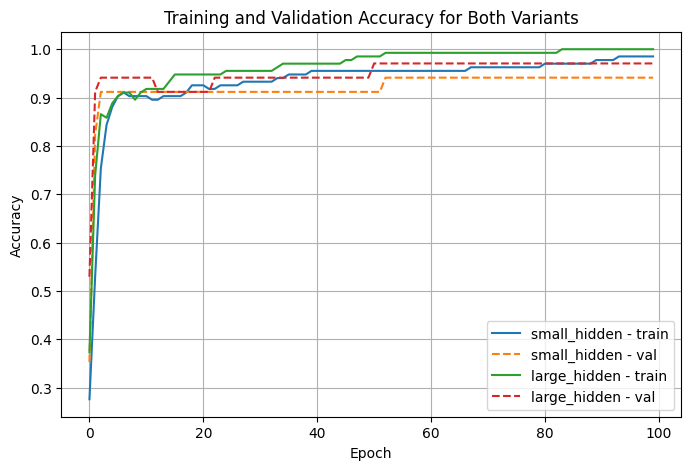

In [9]:
# Plot training and validation accuracy for both variants on shared axes
plt.figure()
for name, history in histories.items():
    plt.plot(history.history['accuracy'], label=f'{name} - train')
    plt.plot(history.history['val_accuracy'], linestyle='--',
             label=f'{name} - val')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for Both Variants')
plt.legend()
plt.show()


**Helper: Evaluation Function**

In [10]:
def evaluate_model(name, model, X_test, y_test, y_test_cat):
    """
    Evaluate model on test data and print accuracy, precision, recall, F1.
    Returns metrics dict and predicted labels.
    """
    # Predict class probabilities and labels
    y_proba = model.predict(X_test)
    y_pred = np.argmax(y_proba, axis=1)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Macro-averaged precision, recall, F1 (treat all classes equally)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred,
        average='macro',
        zero_division=0
    )

    print(f"\n=== Test Metrics for {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    print("\nClassification report:")
    print(classification_report(
        y_test, y_pred,
        target_names=['class 1', 'class 2', 'class 3']
    ))

    metrics = {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }
    return metrics, y_pred


**Evaluate Both Variants on Test Set**

In [11]:
all_metrics = {}
all_preds = {}

for name, model in models.items():
    metrics, y_pred = evaluate_model(
        name, model,
        X_test_scaled, y_test, y_test_cat
    )
    all_metrics[name] = metrics
    all_preds[name] = y_pred

# Put metrics into a DataFrame for easier viewing / report table
metrics_df = pd.DataFrame(all_metrics).T
metrics_df


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

=== Test Metrics for small_hidden ===
Accuracy:  0.8333
Precision: 0.8416
Recall:    0.8333
F1-score:  0.8218

Classification report:
              precision    recall  f1-score   support

     class 1       0.89      0.57      0.70        14
     class 2       0.81      0.93      0.87        14
     class 3       0.82      1.00      0.90        14

    accuracy                           0.83        42
   macro avg       0.84      0.83      0.82        42
weighted avg       0.84      0.83      0.82        42

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step

=== Test Metrics for large_hidden ===
Accuracy:  0.8571
Precision: 0.8634
Recall:    0.8571
F1-score:  0.8499

Classification report:
              precision    recall  f1-score   support

     class 1       0.90      0.64      0.75        14
     class 2       0.87      0.93      0.90        14
     class 3       0.82      1.00      0.90        14

    accuracy                           0.86        42
 

,accuracy,precision,recall,f1
small_hidden,0.833333,0.841639,0.833333,0.821848
large_hidden,0.857143,0.863399,0.857143,0.849926


**Pick Best Variant & Plot Confusion Matrix**

Best variant based on macro F1-score: large_hidden
{'accuracy': 0.8571428571428571, 'precision': 0.8633986928104574, 'recall': 0.8571428571428572, 'f1': 0.849925843529848}


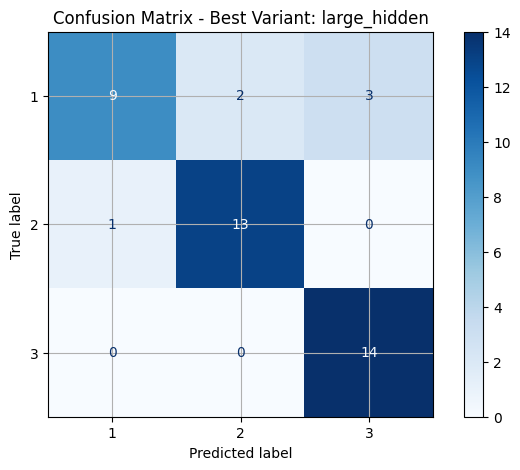

In [12]:
# Select best model based on F1-score (you can also choose accuracy)
best_name = max(all_metrics, key=lambda k: all_metrics[k]['f1'])
best_model = models[best_name]
best_pred = all_preds[best_name]

print(f"Best variant based on macro F1-score: {best_name}")
print(all_metrics[best_name])

# Confusion matrix for best model
cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[1, 2, 3]  # original class labels
)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - Best Variant: {best_name}")
plt.show()


## Model Interpretation Notes

From the comparison, the **large_hidden** model (64 and 32 units) performed slightly better than the **small_hidden** model (32 and 16 units). The larger network achieved a higher macro F1-score on the test set, which means it handled all three classes a bit more evenly.

In the confusion matrix of the best model, class 1 is classified almost perfectly, while most of the mistakes happen between class 2 and class 3. This makes sense because their feature values are quite close. Overall, increasing the hidden layer size helped the model learn more complex decision boundaries without clearly overfitting under the chosen regularization settings.
